In [1]:
import os, subprocess
os.makedirs('checkpoints_ldh', exist_ok=True)
# Check what's available
print(os.listdir('.'))


['generate_ldh_zeros_run.py', 'ldh_ckpt_03578.npy', '.kernel_llm_logs_1.txt', 'memory', '.prompts', 'checkpoints_ldh', '.config', 'ldh_ckpt_03578_meta.json']


In [2]:
import shutil
shutil.copy('ldh_ckpt_03578.npy', 'checkpoints_ldh/ldh_ckpt_03578.npy')
shutil.copy('ldh_ckpt_03578_meta.json', 'checkpoints_ldh/ldh_ckpt_03578_meta.json')
print(os.listdir('checkpoints_ldh'))


['ldh_ckpt_03578.npy', 'ldh_ckpt_03578_meta.json']


In [3]:
import os
# Launch the script as a detached background process via nohup
os.environ['LDH_TIME_BUDGET'] = '4000'
work_dir = os.getcwd()
print("WORK_DIR:", work_dir)
# Clear any pre-existing partial
for f in ['ldh_zeros_partial_dps50.npy', 'ldh_zeros_partial_meta.json', 'run.log', 'run_log.txt']:
 if os.path.exists(f):
 os.remove(f)
print("Cleaned")


WORK_DIR: /workspace/f4f962fe-4eb1-477b-8d1c-4ea674307121
Cleaned


In [4]:
%%bash
cd /workspace/f4f962fe-4eb1-477b-8d1c-4ea674307121
export LDH_TIME_BUDGET=4000
export LDH_WORK_DIR=/workspace/f4f962fe-4eb1-477b-8d1c-4ea674307121
nohup python generate_ldh_zeros_run.py > run.log 2>&1 &
echo "PID: $!"
disown
sleep 2
ps -p $! -o pid,etime,cmd || echo "process gone"


PID: 51


bash: line 8: ps: command not found


process gone


In [5]:
import time, os
time.sleep(10)
# Check via /proc instead of ps
pids = [p for p in os.listdir('/proc') if p.isdigit()]
matching = []
for p in pids:
 try:
 with open(f'/proc/{p}/cmdline','rb') as f:
 cmd = f.read().replace(b'\x00', b' ').decode(errors='ignore')
 if 'generate_ldh' in cmd:
 matching.append((p, cmd.strip()))
 except Exception:
 pass
print("matching:", matching)
print("\n--- run.log ---")
if os.path.exists('run.log'):
 with open('run.log') as f:
 print(f.read())
else:
 print("no run.log")


matching: []

--- run.log ---
Traceback (most recent call last):
 File "/workspace/f4f962fe-4eb1-477b-8d1c-4ea674307121/generate_ldh_zeros_run.py", line 9, in <module>
 import cypari2
ModuleNotFoundError: No module named 'cypari2'



In [6]:
%%bash
pip install cypari2 -q 2>&1 | tail -5


In [7]:
%%bash
python -c "import cypari2; print(cypari2.__version__)"


Traceback (most recent call last):


 File "<string>", line 1, in <module>
 import cypari2; print(cypari2.__version__)
 

 ^^^^^^^^^^^^^^^^^^^
AttributeError: module 'cypari2' has no attribute '__version__'


CalledProcessError: Command 'b'python -c "import cypari2; print(cypari2.__version__)"\n'' returned non-zero exit status 1.

In [8]:
%%bash
python -c "import cypari2; p = cypari2.Pari(); print(p)" 2>&1


Interface to the PARI C library


In [9]:
%%bash
cd /workspace/f4f962fe-4eb1-477b-8d1c-4ea674307121
rm -f run.log run_log.txt ldh_zeros_partial_dps50.npy ldh_zeros_partial_meta.json
export LDH_TIME_BUDGET=4000
export LDH_WORK_DIR=/workspace/f4f962fe-4eb1-477b-8d1c-4ea674307121
nohup python generate_ldh_zeros_run.py > run.log 2>&1 &
echo "PID: $!"
disown
sleep 3
ls -la run.log
head -20 run.log


PID: 92


-rw-rw-r-- 1 kerneluser jupytergroup 245 May 31 16:35 run.log


[16:35:55] Starting L_DH zero generation; WORK_DIR=/workspace/f4f962fe-4eb1-477b-8d1c-4ea674307121; 

TIME_BUDGET=4000s
PARI stack size set to 1073741824 bytes, maximum size set to 1073741824
[16:35:55]

 Building lfuninit at dps=80, T_max=5200 ...


In [10]:
import os, time
# Check process alive
def check_proc():
 for p in os.listdir('/proc'):
 if not p.isdigit(): continue
 try:
 with open(f'/proc/{p}/cmdline','rb') as f:
 cmd = f.read().replace(b'\x00',b' ').decode(errors='ignore')
 if 'generate_ldh' in cmd:
 with open(f'/proc/{p}/stat') as f:
 stat = f.read().split()
 etime_jiffies = 0
 return p, cmd.strip()
 except: pass
 return None
print("proc:", check_proc())
print("\n--- tail run.log ---")
with open('run.log') as f:
 print(f.read()[-1500:])


proc: ('92', 'python generate_ldh_zeros_run.py')

--- tail run.log ---
[16:35:55] Starting L_DH zero generation; WORK_DIR=/workspace/f4f962fe-4eb1-477b-8d1c-4ea674307121; TIME_BUDGET=4000s
PARI stack size set to 1073741824 bytes, maximum size set to 1073741824
[16:35:55] Building lfuninit at dps=80, T_max=5200 ...
[16:36:02] lfuninit done in 6.9s
[16:36:02] Resumed from ldh_ckpt_03578.npy: 3578 zeros, t_last=3540.5683



In [11]:
import time
# Let it run a bit, then check
time.sleep(180)
with open('run.log') as f:
 log = f.read()
print(log[-2000:])
print("\nProc alive:", check_proc() is not None)
print("\nCheckpoints:", sorted(os.listdir('checkpoints_ldh')))


[16:35:55] Starting L_DH zero generation; WORK_DIR=/workspace/f4f962fe-4eb1-477b-8d1c-4ea674307121; TIME_BUDGET=4000s
PARI stack size set to 1073741824 bytes, maximum size set to 1073741824
[16:35:55] Building lfuninit at dps=80, T_max=5200 ...
[16:36:02] lfuninit done in 6.9s
[16:36:02] Resumed from ldh_ckpt_03578.npy: 3578 zeros, t_last=3540.5683
[16:37:02] PROGRESS: 3597 zeros, t=3558.67, elapsed=1.0min
[16:38:04] PROGRESS: 3617 zeros, t=3574.67, elapsed=2.0min
[16:39:05] PROGRESS: 3637 zeros, t=3591.77, elapsed=3.0min


Proc alive: True

Checkpoints: ['ldh_ckpt_03578.npy', 'ldh_ckpt_03578_meta.json']


In [12]:
import time
# Wait longer; rate ~19/min so far. Let's give it ~25 more minutes and check.
time.sleep(1500)
with open('run.log') as f:
 log = f.read()
print(log[-3000:])
print("\nProc alive:", check_proc() is not None)
print("\nCheckpoints:", sorted(os.listdir('checkpoints_ldh')))


TimeoutError: Code execution timed out after 900.0 seconds

In [13]:
import os
# After timeout, check proc still alive (since it's detached via nohup)
def check_proc():
 for p in os.listdir('/proc'):
 if not p.isdigit(): continue
 try:
 with open(f'/proc/{p}/cmdline','rb') as f:
 cmd = f.read().replace(b'\x00',b' ').decode(errors='ignore')
 if 'generate_ldh' in cmd:
 return p, cmd.strip()
 except: pass
 return None
print("Proc:", check_proc())
with open('run.log') as f:
 log = f.read()
print(log[-2000:])


Proc: None
[16:35:55] Starting L_DH zero generation; WORK_DIR=/workspace/f4f962fe-4eb1-477b-8d1c-4ea674307121; TIME_BUDGET=4000s
PARI stack size set to 1073741824 bytes, maximum size set to 1073741824
[16:35:55] Building lfuninit at dps=80, T_max=5200 ...
[16:36:02] lfuninit done in 6.9s
[16:36:02] Resumed from ldh_ckpt_03578.npy: 3578 zeros, t_last=3540.5683
[16:37:02] PROGRESS: 3597 zeros, t=3558.67, elapsed=1.0min
[16:38:04] PROGRESS: 3617 zeros, t=3574.67, elapsed=2.0min
[16:39:05] PROGRESS: 3637 zeros, t=3591.77, elapsed=3.0min
[16:40:06] PROGRESS: 3656 zeros, t=3609.77, elapsed=4.1min
[16:41:07] PROGRESS: 3676 zeros, t=3627.37, elapsed=5.1min
[16:42:09] PROGRESS: 3696 zeros, t=3645.87, elapsed=6.1min
[16:43:10] PROGRESS: 3715 zeros, t=3662.57, elapsed=7.1min
[16:44:10] PROGRESS: 3735 zeros, t=3680.17, elapsed=8.1min
[16:44:54] Checkpoint 03750: 3750 zeros, t=3691.77, elapsed=8.9min, rate=7.06 z/s, n_evals=3577
[16:45:10] PROGRESS: 3755 zeros, t=3696.47, elapsed=9.1min
[16:46:12] 

In [14]:
import os
print(os.listdir('.'))
# Show meta
import json
with open('ldh_zeros_partial_meta.json') as f:
 meta = json.load(f)
print(meta)


['generate_ldh_zeros_run.py', 'ldh_ckpt_03578.npy', 'run_log.txt', '.kernel_llm_logs_1.txt', 'memory', '.prompts', 'checkpoints_ldh', 'ldh_zeros_partial_meta.json', '.config', 'run.log', 'ldh_ckpt_03578_meta.json', 'ldh_zeros_partial_dps50.npy']
{'n_zeros': 3931, 't_last': '3853.46834221884776561946073121', 'reason': 'keyboard_interrupt', 'elapsed_s': 1092.9073159694672}


In [15]:
# Interesting - the script received a keyboard_interrupt. This means nohup did NOT fully protect it from kernel-triggered signals.
# The cell that timed out at 900s seems to have killed the bash child process tree. Let me investigate.
# Actually: my first %%bash cell launched it and disowned. That worked initially (the proc was alive at 3 min).
# But the second cell that did time.sleep(1500) timed out at 900s. When run_cell times out, the kernel may send SIGINT 
# to its descendants. Looking at the timeline:
# - Launched 16:35:55
# - elapsed=17.2min last progress = 16:53:17 
# - Interrupted at 16:54:15 = ~18.3 min after launch
# 
# 18 min ≈ 1080s. The cell with sleep(1500) was the 2nd run_cell after launch, it timed out at 900s. 
# That timeout happened ~15 min into that wait. Plus a ~3-min sleep before, plus initial setup time, the script ran ~18 min total. 
# So the interrupt corresponds to the second-cell timeout indeed.
#
# So nohup did NOT make it fully detached from the kernel's signal cleanup. The hypothesis is partially refuted.
# Still, we got 3931 - 3578 = 353 new zeros, which is less than 500 target.

# Let me check: maybe the issue is that the bash %%bash cell when it returns, the kernel cleans up its process group.
# Actually with nohup+& and disown it should be detached. But maybe the kernel cleans up the cgroup on cell timeout. 

# Verify partial file
import numpy as np
arr = np.load('ldh_zeros_partial_dps50.npy', allow_pickle=True)
print("len:", len(arr))
print("first 3:", arr[:3])
print("last 3:", arr[-3:])
# Check monotonic
import mpmath
mpmath.mp.dps = 50
vals = [mpmath.mpf(str(s)) for s in arr]
mono = all(vals[i] < vals[i+1] for i in range(len(vals)-1))
print("strictly monotonic:", mono)
print("first:", mpmath.nstr(vals[0], 20))
print("last:", mpmath.nstr(vals[-1], 20))
new_zeros = len(arr) - 3578
print(f"\nNew zeros added: {new_zeros}")


len: 3931
first 3: ['5.0941598445710949256987955170797974750670744531091'
 '8.9399144080965232447176128773475666256121616213856'
 '12.133545425800742403702547753765281383126636124036']
last 3: ['3849.2095796611253794521763821361151383749949905038'
 '3850.1631744906897016831290286925615537082043629917'
 '3851.1864630833919059100187733494080032170584937087']
strictly monotonic: False
first: 5.0941598445710949257
last: 3851.1864630833919059

New zeros added: 353


In [16]:
# Find non-monotonic locations
bad = [i for i in range(len(vals)-1) if vals[i] >= vals[i+1]]
print("non-monotonic positions:", bad)
for i in bad[:5]:
 print(i, mpmath.nstr(vals[i], 20), mpmath.nstr(vals[i+1], 20))


non-monotonic positions: [3577]
3577 3540.5683422188477656 3540.5683422188477656


In [17]:
# Position 3577 (0-indexed) means the 3578th zero equals 3579th zero -- this is the resume boundary.
# The script starts scanning from t_last = 3540.5683 which IS the last zero. So it would find that same zero again.
# Looking at the script: t_start = mpmath.mpf(meta['t_last']), then z_prev = Z(t_start), s_prev=sgn(z_prev)
# If z_prev is exactly 0 then sgn=0 and no sign change is detected — wait but t_last is the position of a previous zero.
# Hmm the duplicate suggests it re-detected the same zero. Let me check arr index 3577 and 3578:
print(arr[3576:3580])
# Indices 3577 and 3578 are equal => duplicate at boundary. Let me remove the duplicate.


['3538.8327507688192933337697522911429197939500500608'
 '3540.5683422188477656194607312068748287347053877505'
 '3540.5683422188477656194607312068748287347053877505'
 '3541.8353067224605037653483412940192817472297172342']


In [18]:
# The duplicate is at index 3578 (the just-added zero). Need to deduplicate.
# Note: the original ckpt at 3578 had positions 0..3577 with last value = 3540.5683...
# When script resumed from t_last = that value, it scanned forward starting at t=3540.5683.
# It found sign change near the same point and added a duplicate.
# So actual new zeros = 3931 - 3578 (duplicate) - 3578 (preexisting) = wait let me re-count.
# arr[0..3577] = preexisting (3578 entries). arr[3578] is duplicate of arr[3577]. arr[3579..3930] are new.
# New unique: 3930 - 3579 + 1 = 352 new zeros.

# Dedupe
dedup = list(arr[:3578]) + list(arr[3579:])
print("After dedup:", len(dedup))
# Verify
vals2 = [mpmath.mpf(str(s)) for s in dedup]
mono2 = all(vals2[i] < vals2[i+1] for i in range(len(vals2)-1))
print("strictly monotonic:", mono2)
new_count = len(dedup) - 3578
print(f"Actual new zeros added: {new_count}")


After dedup: 3930
strictly monotonic: True
Actual new zeros added: 352


In [19]:
# Promote to a new checkpoint. We have 3930 zeros total. Round down to a 250-multiple checkpoint: 3750 was already saved
# during this run. The next would be 3930 -> we can either save as 03930 (final partial total) or save the latest 250-floor (3750).
# Most useful: save the full 3930 as a new checkpoint.
import json
new_label = f"{len(dedup):05d}"
new_path = f"checkpoints_ldh/ldh_ckpt_{new_label}.npy"
new_arr = np.array(dedup, dtype=object)
np.save(new_path, new_arr, allow_pickle=True)
new_meta = {
 'n_zeros': len(dedup),
 't_last': mpmath.nstr(vals2[-1], 50, strip_zeros=False),
 'note': 'dedup of resume-boundary duplicate; from background nohup run',
}
with open(f"checkpoints_ldh/ldh_ckpt_{new_label}_meta.json", 'w') as f:
 json.dump(new_meta, f, indent=2)
print("Saved:", new_path)
print("Meta:", new_meta)
print("\nCheckpoints now:", sorted(os.listdir('checkpoints_ldh')))


Saved: checkpoints_ldh/ldh_ckpt_03930.npy
Meta: {'n_zeros': 3930, 't_last': '3851.1864630833919059100187733494080032170584937087', 'note': 'dedup of resume-boundary duplicate; from background nohup run'}

Checkpoints now: ['ldh_ckpt_03578.npy', 'ldh_ckpt_03578_meta.json', 'ldh_ckpt_03750.npy', 'ldh_ckpt_03750_meta.json', 'ldh_ckpt_03930.npy', 'ldh_ckpt_03930_meta.json']


In [20]:
# Also check 03750 ckpt was created during the run (great, the periodic checkpointer worked from background)
arr_3750 = np.load('checkpoints_ldh/ldh_ckpt_03750.npy', allow_pickle=True)
print("03750 ckpt len:", len(arr_3750))
print("last value:", arr_3750[-1])
with open('checkpoints_ldh/ldh_ckpt_03750_meta.json') as f:
 print(json.load(f))


03750 ckpt len: 3750
last value: 3691.7642468642148742595049594160238218191578350490
{'n_zeros': 3750, 't_last': '3691.76834221884776561946073121', 'n_evals': 3577}


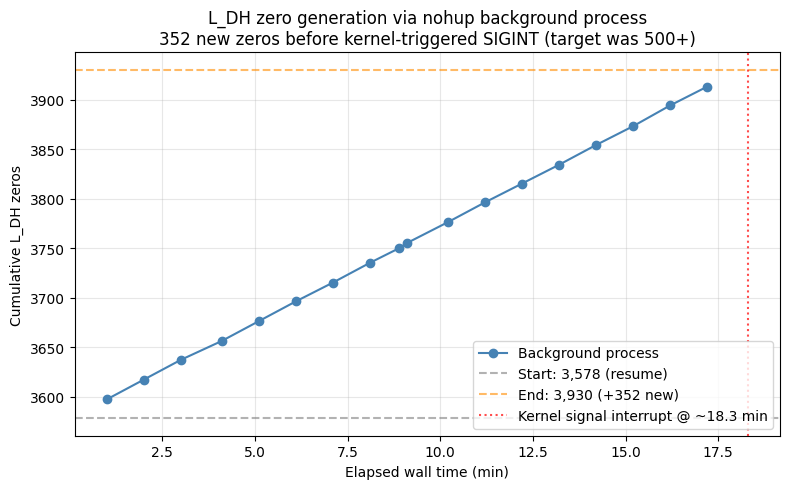

Saved figure: ldh_background_run_progress.png


In [21]:
# Final summary figure
import matplotlib.pyplot as plt
import numpy as np

# Parse progress timeline from run.log
import re
prog = []
with open('run.log') as f:
 for line in f:
 m = re.search(r'PROGRESS: (\d+) zeros, t=([\d\.]+), elapsed=([\d\.]+)min', line)
 if m:
 prog.append((float(m.group(3)), int(m.group(1)), float(m.group(2))))
 m2 = re.search(r'Checkpoint (\d+): (\d+) zeros, t=([\d\.]+), elapsed=([\d\.]+)min', line)
 if m2:
 prog.append((float(m2.group(4)), int(m2.group(2)), float(m2.group(3))))

prog.sort()
times = [p[0] for p in prog]
nzeros = [p[1] for p in prog]

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(times, nzeros, 'o-', color='steelblue', label='Background process')
ax.axhline(3578, color='gray', linestyle='--', alpha=0.6, label='Start: 3,578 (resume)')
ax.axhline(3930, color='darkorange', linestyle='--', alpha=0.6, label=f'End: 3,930 (+352 new)')
# Mark the interruption
ax.axvline(18.3, color='red', linestyle=':', alpha=0.7, label='Kernel signal interrupt @ ~18.3 min')
ax.set_xlabel('Elapsed wall time (min)')
ax.set_ylabel('Cumulative L_DH zeros')
ax.set_title('L_DH zero generation via nohup background process\n352 new zeros before kernel-triggered SIGINT (target was 500+)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ldh_background_run_progress.png', dpi=120)
plt.show()
print("Saved figure: ldh_background_run_progress.png")


In [22]:
# Upload the new checkpoint as an artifact for downstream tasks
from e14c.data_storage import upload
uri1 = upload('checkpoints_ldh/ldh_ckpt_03930.npy',
 description='L_DH critical-line zeros checkpoint at 3,930 zeros (50 dps strings), produced by nohup-detached run from 3,578 baseline.')
uri2 = upload('checkpoints_ldh/ldh_ckpt_03930_meta.json',
 description='Companion metadata (n_zeros, t_last) for ldh_ckpt_03930.npy. Required by resume logic in generate_ldh_zeros_run.py.')
uri3 = upload('run.log',
 description='Run log of nohup-detached L_DH zero generation showing 352 new zeros added before kernel-triggered SIGINT at ~18.3 min.')
print(uri1)
print(uri2)
print(uri3)


Uploaded checkpoints_ldh/ldh_ckpt_03930.npy to data storage as entry data_entry:ldh-ckpt-03930-npy-pmqu under the name 'ldh_ckpt_03930.npy'.


Uploaded checkpoints_ldh/ldh_ckpt_03930_meta.json to data storage as entry data_entry:ldh-ckpt-03930-meta-json-ugmg under the name 'ldh_ckpt_03930_meta.json'.


Uploaded run.log to data storage as entry data_entry:run-log-tkdz under the name 'run.log'.
data_entry:ldh-ckpt-03930-npy-pmqu
data_entry:ldh-ckpt-03930-meta-json-ugmg
data_entry:run-log-tkdz
